# SpaceX Falcon 9 Capstone — Master Notebook

This notebook runs **Labs 1, 2, 3, 4, 5, 6, and 8** end-to-end in a single session, so every CSV/HTML output persists in memory and on disk for the whole run. **Lab 7 (Plotly Dash) is not included here** — it needs to run as a standalone script on your own machine (Dash needs a persistent local server, which doesn't work well inside Colab).

**Instructions:**
1. Runtime → Run all
2. Wait for every cell to finish (Lab 8's GridSearchCV models can take a few minutes)
3. Run the final 'Zip everything' cell at the bottom
4. Download the resulting `spacex_capstone_outputs.zip` from the file panel on the left — this contains every CSV, notebook output, and map you need for your report.

---
# LAB 1: Data Collection - SpaceX API

In [1]:
import requests
import pandas as pd
import numpy as np
import datetime
import time
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Session with automatic retries -- the SpaceX API occasionally returns 5xx errors
session = requests.Session()
retries = Retry(total=5, backoff_factor=1.5, status_forcelist=[500, 502, 503, 504, 525])
session.mount('https://', HTTPAdapter(max_retries=retries))

## 1. Request past launch data from the API

In [2]:
spacex_url = "https://api.spacexdata.com/v4/launches/past"
response = requests.get(spacex_url)
print("Status code:", response.status_code)

# The live SpaceX API is often unstable and returns 5xx errors (e.g. 525).
# If that happens, fall back to IBM's static snapshot of the same dataset.
if response.status_code != 200:
    print("Live API unavailable, falling back to static snapshot...")
    static_json_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/API_call_spacex_api.json'
    response = requests.get(static_json_url)
    print("Static source status code:", response.status_code)

data = pd.json_normalize(response.json())
data.head()

Status code: 525
Live API unavailable, falling back to static snapshot...
Static source status code: 200


,static_fire_date_utc,static_fire_date_unix,tbd,net,window,rocket,success,details,crew,ships,capsules,payloads,launchpad,auto_update,failures,flight_number,name,date_utc,date_unix,date_local,date_precision,upcoming,cores,id,fairings.reused,fairings.recovery_attempt,fairings.recovered,fairings.ships,links.patch.small,links.patch.large,links.reddit.campaign,links.reddit.launch,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Engine failure at 33 seconds and loss of vehicle,[],[],[],[5eb0e4b5b6c3bb0006eeb1e1],5e9e4502f5090995de566f86,True,"[{'time': 33, 'altitude': None, 'reason': 'merlin engine failure'}]",1,FalconSat,2006-03-24T22:30:00.000Z,1143239400,2006-03-25T10:30:00+12:00,hour,False,"[{'core': '5e9e289df35918033d3b2623', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cd9ffd86e000604b32a,False,False,False,[],https://images2.imgbox.com/3c/0e/T8iJcSN3_o.png,https://images2.imgbox.com/40/e3/GypSkayF_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html,https://en.wikipedia.org/wiki/DemoSat,NaN
1,None,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,"Successful first stage burn and transition to second stage, maximum altitude 289 km, Premature engine shutdown at T+7 min 30 s, Failed to reach orbit, Failed to recover first stage",[],[],[],[5eb0e4b6b6c3bb0006eeb1e2],5e9e4502f5090995de566f86,True,"[{'time': 301, 'altitude': 289, 'reason': 'harmonic oscillation leading to premature engine shutdown'}]",2,DemoSat,2007-03-21T01:10:00.000Z,1174439400,2007-03-21T13:10:00+12:00,hour,False,"[{'core': '5e9e289ef35918416a3b2624', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cdaffd86e000604b32b,False,False,False,[],https://images2.imgbox.com/4f/e3/I0lkuJ2e_o.png,https://images2.imgbox.com/be/e7/iNqsqVYM_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-rocket-fails-reach-orbit.html,https://en.wikipedia.org/wiki/DemoSat,NaN
2,None,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Residual stage 1 thrust led to collision between stage 1 and stage 2,[],[],[],"[5eb0e4b6b6c3bb0006eeb1e3, 5eb0e4b6b6c3bb0006eeb1e4]",5e9e4502f5090995de566f86,True,"[{'time': 140, 'altitude': 35, 'reason': 'residual stage-1 thrust led to collision between stage 1 and stage 2'}]",3,Trailblazer,2008-08-03T03:34:00.000Z,1217734440,2008-08-03T15:34:00+12:00,hour,False,"[{'core': '5e9e289ef3591814873b2625', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cdbffd86e000604b32c,False,False,False,[],https://images2.imgbox.com/3d/86/cnu0pan8_o.png,https://images2.imgbox.com/4b/bd/d8UxLh4q_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1-flight-3-mission-summary,https://en.wikipedia.org/wiki/Trailblazer_(satellite),NaN
3,2008-09-20T00:00:00.000Z,1.221869e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,True,"Ratsat was carried to orbit on the first successful orbital launch of any privately funded and developed, liquid-propelled carrier rocket, the SpaceX Falcon 1",[],[],[],[5eb0e4b7b6c3bb0006eeb1e5],5e9e4502f5090995de566f86,True,[],4,RatSat,2008-09-28T23:15:00.000Z,1222643700,2008-09-28T11:15:00+12:00,hour,False,"[{'core': '5e9e289ef3591855dc3b2626', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_succes

## 2. Keep the columns we need and remove multi-value rows
We only need launches with a single core and a single payload, since we're studying first-stage landing outcomes.

In [3]:
data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]

# Keep single-core, single-payload launches only
data = data[data['cores'].map(len) == 1]
data = data[data['payloads'].map(len) == 1]

data['cores'] = data['cores'].map(lambda x: x[0])
data['payloads'] = data['payloads'].map(lambda x: x[0])

# Convert date_utc into a date and restrict to on/before a fixed cutoff for reproducibility
data['date'] = pd.to_datetime(data['date_utc']).dt.date
data = data[data['date'] <= datetime.date(2020, 11, 13)]

data.reset_index(drop=True, inplace=True)
data.head()

,rocket,payloads,launchpad,cores,flight_number,date_utc,date
0,5e9d0d95eda69955f709d1eb,5eb0e4b5b6c3bb0006eeb1e1,5e9e4502f5090995de566f86,"{'core': '5e9e289df35918033d3b2623', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}",1,2006-03-24T22:30:00.000Z,2006-03-24
1,5e9d0d95eda69955f709d1eb,5eb0e4b6b6c3bb0006eeb1e2,5e9e4502f5090995de566f86,"{'core': '5e9e289ef35918416a3b2624', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}",2,2007-03-21T01:10:00.000Z,2007-03-21
2,5e9d0d95eda69955f709d1eb,5eb0e4b7b6c3bb0006eeb1e5,5e9e4502f5090995de566f86,"{'core': '5e9e289ef3591855dc3b2626', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}",4,2008-09-28T23:15:00.000Z,2008-09-28
3,5e9d0d95eda69955f709d1eb,5eb0e4b7b6c3bb0006eeb1e6,5e9e4502f5090995de566f86,"{'core': '5e9e289ef359184f103b2627', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}",5,2009-07-13T03:35:00.000Z,2009-07-13
4,5e9d0d95eda69973a809d1ec,5eb0e4b7b6c3bb0006eeb1e7,5e9e4501f509094ba4566f84,"{'core': '5e9e289ef359185f2b3b2628', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}",6,2010-06-04T18:45:00.000Z,2010-06-04


## 3. Helper functions to resolve rocket / launchpad / payload / core IDs into readable values
Each field above is just an ID that references another API endpoint. We look each one up.

In [4]:
BoosterVersion, PayloadMass, Orbit, LaunchSite = [], [], [], []
Outcome, Flights, GridFins, Reused, Legs = [], [], [], [], []
LandingPad, Block, ReusedCount, Serial = [], [], [], []
Longitude, Latitude = [], []

def getBoosterVersion(data):
    for x in data['rocket']:
        if x:
            response = session.get("https://api.spacexdata.com/v4/rockets/"+str(x)).json()
            BoosterVersion.append(response['name'])

def getLaunchSite(data):
    for x in data['launchpad']:
        if x:
            response = session.get("https://api.spacexdata.com/v4/launchpads/"+str(x)).json()
            Longitude.append(response['longitude'])
            Latitude.append(response['latitude'])
            LaunchSite.append(response['name'])

def getPayloadData(data):
    for load in data['payloads']:
        if load:
            response = session.get("https://api.spacexdata.com/v4/payloads/"+str(load)).json()
            PayloadMass.append(response['mass_kg'])
            Orbit.append(response['orbit'])

def getCoreData(data):
    for core in data['cores']:
        if core['core'] is not None:
            response = session.get("https://api.spacexdata.com/v4/cores/"+str(core['core'])).json()
            Block.append(response['block'])
            ReusedCount.append(response['reuse_count'])
            Serial.append(response['serial'])
        else:
            Block.append(None)
            ReusedCount.append(None)
            Serial.append(None)
        Outcome.append(str(core['landing_success'])+' '+str(core['landing_type']))
        Flights.append(core['flight'])
        GridFins.append(core['gridfins'])
        Reused.append(core['reused'])
        Legs.append(core['legs'])
        LandingPad.append(core['landpad'])

In [5]:
# The SpaceX API is currently returning intermittent 525 errors on many of these
# per-launch lookups. If that happens, we fall back to IBM's official static
# snapshot of the finished dataset (same schema this lab produces).
api_lookup_failed = False
try:
    getBoosterVersion(data)
    getLaunchSite(data)
    getPayloadData(data)
    getCoreData(data)
    print(len(BoosterVersion), len(LaunchSite), len(PayloadMass), len(Outcome))
except Exception as e:
    print('API lookups failed:', e)
    api_lookup_failed = True

API lookups failed: HTTPSConnectionPool(host='api.spacexdata.com', port=443): Max retries exceeded with url: /v4/rockets/5e9d0d95eda69955f709d1eb (Caused by ResponseError('too many 525 error responses'))


## 4. Assemble the final dataset

In [6]:
if not api_lookup_failed:
    launch_dict = {
        'FlightNumber': list(data['flight_number']),
        'Date': list(data['date']),
        'BoosterVersion': BoosterVersion,
        'PayloadMass': PayloadMass,
        'Orbit': Orbit,
        'LaunchSite': LaunchSite,
        'Outcome': Outcome,
        'Flights': Flights,
        'GridFins': GridFins,
        'Reused': Reused,
        'Legs': Legs,
        'LandingPad': LandingPad,
        'Block': Block,
        'ReusedCount': ReusedCount,
        'Serial': Serial,
        'Longitude': Longitude,
        'Latitude': Latitude
    }
    df = pd.DataFrame(launch_dict)
else:
    # Fallback: IBM's static snapshot of the finished dataset_part_1.csv,
    # produced by running this exact same pipeline against a working API.
    fallback_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv'
    df = pd.read_csv(fallback_url)
    print('Loaded fallback dataset_part_1.csv with', df.shape[0], 'rows')

df.head()

Loaded fallback dataset_part_1.csv with 90 rows


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857


## 5. Filter to Falcon 9 only and handle missing PayloadMass

In [7]:
data_falcon9 = df[df['BoosterVersion'] != 'Falcon 1']
data_falcon9.loc[:, 'FlightNumber'] = list(range(1, data_falcon9.shape[0]+1))

# Fill missing payload mass with the column mean
mean_mass = data_falcon9['PayloadMass'].mean()
data_falcon9.loc[:, 'PayloadMass'] = data_falcon9['PayloadMass'].fillna(mean_mass)

print(data_falcon9.isnull().sum())
data_falcon9.head()

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
dtype: int64


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857


## 6. Export to CSV for the next lab

In [8]:
data_falcon9.to_csv('dataset_part_1.csv', index=False)
print('Saved dataset_part_1.csv with', data_falcon9.shape[0], 'rows')

Saved dataset_part_1.csv with 90 rows


---
# LAB 2: Data Collection - Web Scraping

In [9]:
!pip install beautifulsoup4 requests -q

In [10]:
import requests
import pandas as pd
import re
import unicodedata
from bs4 import BeautifulSoup

## 1. Helper functions to parse each table cell
Wikipedia's launch table packs a lot into each cell (dates with footnotes, booster version with links, etc). These helpers pull out just the clean value.

In [11]:
def date_time(table_cells):
    return [date_time.strip() for date_time in list(table_cells.strings)][0:2]

def booster_version(table_cells):
    out = ''.join([booster_version for i, booster_version in enumerate(table_cells.strings) if i % 2 == 0][0:-1])
    return out

def landing_status(table_cells):
    out = [i for i in table_cells.strings][0]
    return out

def get_mass(table_cells):
    mass = unicodedata.normalize("NFKD", table_cells.text).strip()
    if mass:
        mass.find("kg")
        new_mass = mass[0:mass.find("kg")+2]
    else:
        new_mass = 0
    return new_mass

def extract_column_from_header(row):
    if row.br:
        row.br.extract()
    if row.a:
        row.a.extract()
    if row.sup:
        row.sup.extract()
    column_name = ' '.join(row.contents)
    if not column_name.strip().isdigit():
        column_name = column_name.strip()
        return column_name

## 2. Request the fixed Wikipedia revision and build the soup object

In [12]:
static_url = "https://en.wikipedia.org/w/index.php?title=List_of_Falcon_9_and_Falcon_Heavy_launches&oldid=1027686922"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                  '(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

response = requests.get(static_url, headers=headers)
print("Status code:", response.status_code)
print("Content length:", len(response.text))

soup = BeautifulSoup(response.text, 'html.parser')
print(soup.title)

Status code: 200
Content length: 3282496
<title>List of Falcon 9 and Falcon Heavy launches - Wikipedia</title>


## 3. Find all launch tables and extract column names

In [13]:
html_tables = soup.find_all('table')
print("Number of tables found:", len(html_tables))

if len(html_tables) == 0:
    print("No tables found — check status code and content length above.")
    print("First 500 chars of response:")
    print(response.text[:500])
else:
    # The launch records table is (usually) the 3rd table on the page (index 2).
    # If parsing looks wrong later, print a few tables' first rows to find the right index.
    first_launch_table = html_tables[2] if len(html_tables) > 2 else html_tables[0]

    column_names = []
    for th in first_launch_table.find_all('th'):
        name = extract_column_from_header(th)
        if name is not None and len(name) > 0:
            column_names.append(name)

    print(column_names)

Number of tables found: 25
['Flight No.', 'Date and time ( )', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome']


## 4. Parse every row of every launch table into a dictionary

In [14]:
launch_dict = dict.fromkeys(column_names)

# Remove irrelevant columns and set up the fields we actually need
del launch_dict['Date and time ( )']

launch_dict['Flight No.'] = []
launch_dict['Launch site'] = []
launch_dict['Payload'] = []
launch_dict['Payload mass'] = []
launch_dict['Orbit'] = []
launch_dict['Customer'] = []
launch_dict['Launch outcome'] = []
launch_dict['Version Booster'] = []
launch_dict['Booster landing'] = []
launch_dict['Date'] = []
launch_dict['Time'] = []

In [15]:
extracted_row = 0

for table_number, table in enumerate(soup.find_all('table', "wikitable plainrowheaders collapsible")):
    for rows in table.find_all("tr"):
        if rows.th:
            if rows.th.string:
                flight_number = rows.th.string.strip()
                flag = flight_number.isdigit()
        else:
            flag = False

        row = rows.find_all('td')

        if flag:
            extracted_row += 1
            launch_dict['Flight No.'].append(flight_number)

            datatimelist = date_time(row[0])
            launch_dict['Date'].append(datatimelist[0].strip(','))
            launch_dict['Time'].append(datatimelist[1] if len(datatimelist) > 1 else None)

            bv = booster_version(row[1])
            if not bv:
                bv = row[1].a.string if row[1].a else None
            launch_dict['Version Booster'].append(bv)

            launch_site = row[2].a.string if row[2].a else row[2].text.strip()
            launch_dict['Launch site'].append(launch_site)

            payload = row[3].a.string if row[3].a else row[3].text.strip()
            launch_dict['Payload'].append(payload)

            payload_mass = get_mass(row[4])
            launch_dict['Payload mass'].append(payload_mass)

            orbit = row[5].a.string if row[5].a else row[5].text.strip()
            launch_dict['Orbit'].append(orbit)

            customer = row[6].a.string if row[6].a else row[6].text.strip()
            launch_dict['Customer'].append(customer)

            launch_outcome = list(row[7].strings)[0].strip()
            launch_dict['Launch outcome'].append(launch_outcome)

            booster_landing = landing_status(row[8])
            launch_dict['Booster landing'].append(booster_landing)

print("Rows extracted:", extracted_row)

Rows extracted: 121


## 5. Build the DataFrame and save to CSV

In [16]:
df = pd.DataFrame({key: pd.Series(value) for key, value in launch_dict.items()})
df.head()

,Flight No.,Launch site,Payload,Payload mass,Orbit,Customer,Launch outcome,Version Booster,Booster landing,Date,Time
0,1,CCAFS,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,F9 v1.07B0003.1,Failure,4 June 2010,18:45
1,2,CCAFS,Dragon,0,LEO,NASA,Success,F9 v1.07B0004.1,Failure,8 December 2010,15:43
2,3,CCAFS,Dragon,525 kg,LEO,NASA,Success,F9 v1.07B0005.1,No,22 May 2012,07:44
3,4,CCAFS,SpaceX CRS-1,"4,700 kg",LEO,NASA,Success,F9 v1.07B0006.1,No attempt,8 October 2012,00:35
4,5,CCAFS,SpaceX CRS-2,"4,877 kg",LEO,NASA,Success,F9 v1.07B0007.1,No,1 March 2013,15:10


In [17]:
df.to_csv('spacex_web_scraped.csv', index=False)
print('Saved spacex_web_scraped.csv with', df.shape[0], 'rows')

Saved spacex_web_scraped.csv with 121 rows


---
# LAB 3: Data Wrangling

In [18]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

## 1. Load the dataset from Lab 1
Upload `dataset_part_1.csv` to this Colab session first (folder icon on the left → upload), or read it straight from GitHub if you already pushed it there.

In [19]:
import os

if os.path.exists('dataset_part_1.csv'):
    df = pd.read_csv('dataset_part_1.csv')
else:
    # Not found locally in this session -- load the same dataset from IBM's hosted copy
    print('dataset_part_1.csv not found locally, loading from IBM dataset repository...')
    fallback_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv'
    df = pd.read_csv(fallback_url)

df.head(10)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857
5,6,2014-01-06,Falcon 9,3325.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1005,-80.577366,28.561857
6,7,2014-04-18,Falcon 9,2296.000000,ISS,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1006,-80.577366,28.561857
7,8,2014-07-14,Falcon 9,1316.000000,LEO,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1007,-80.577366,28.561857
8,9,2014-08-05,Falcon 9,4535.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1008,-80.577366,28.561857
9,10,2014-09-07,Falcon 9,4428.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1011,-80.577366,28.561857


## 2. Identify missing values

In [20]:
df.isnull().sum() / df.shape[0] * 100

,0
FlightNumber,0.000000
Date,0.000000
BoosterVersion,0.000000
PayloadMass,0.000000
Orbit,0.000000
LaunchSite,0.000000
Outcome,0.000000
Flights,0.000000
GridFins,0.000000
Reused,0.000000


In [21]:
df.dtypes

,0
FlightNumber,int64
Date,object
BoosterVersion,object
PayloadMass,float64
Orbit,object
LaunchSite,object
Outcome,object
Flights,int64
GridFins,bool
Reused,bool


Note: `LandingPad` will have missing values by design — a missing landing pad ID simply means the booster wasn't attempting a ground/drone-ship landing at all (e.g. it was expended). We'll leave those as NaN rather than dropping rows, since that's informative in itself.

## 3. Summarize launch sites and orbits

In [22]:
print("Launches per site:")
print(df['LaunchSite'].value_counts())
print()
print("Launches per orbit:")
print(df['Orbit'].value_counts())

Launches per site:
LaunchSite
CCAFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64

Launches per orbit:
Orbit
GTO      27
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
HEO       1
ES-L1     1
SO        1
GEO       1
Name: count, dtype: int64


## 4. Build the landing outcome label
The `Outcome` column looks like `'True ASDS'`, `'False ASDS'`, `'True RTLS'`, `'None None'`, etc. — a landing success/failure flag plus a landing type. We split this into a **bad outcomes** set (failures, or no landing attempted) and everything else counts as a successful landing.

In [23]:
print(df['Outcome'].value_counts())

Outcome
True ASDS      41
None None      19
True RTLS      14
False ASDS      6
True Ocean      5
False Ocean     2
None ASDS       2
False RTLS      1
Name: count, dtype: int64


In [24]:
landing_outcomes = df['Outcome'].value_counts()

bad_outcomes = set(landing_outcomes.keys()[[1, 3, 5, 6, 7]])
print("Bad outcomes:", bad_outcomes)

Bad outcomes: {'False ASDS', 'False RTLS', 'None None', 'False Ocean', 'None ASDS'}


**Important:** the indices `[1, 3, 5, 6, 7]` above depend on the order `value_counts()` printed in the previous cell. Re-check that printout for *your* data — the bad outcomes should be things like `False ASDS`, `False Ocean`, `False RTLS`, `None ASDS`, `None None` (i.e. anything starting with `False`, plus attempts with no confirmed landing type). Adjust the index list if your ordering differs.

In [25]:
landing_class = [0 if outcome in bad_outcomes else 1 for outcome in df['Outcome']]
df['Class'] = landing_class

df[['Outcome', 'Class']].head(10)

,Outcome,Class
0,None None,0
1,None None,0
2,None None,0
3,False Ocean,0
4,None None,0
5,None None,0
6,True Ocean,1
7,True Ocean,1
8,None None,0
9,None None,0


In [26]:
success_rate = df['Class'].mean()
print(f"Overall landing success rate: {success_rate:.2%}")

Overall landing success rate: 66.67%


## 5. Export the wrangled dataset for EDA and modeling

In [27]:
df.to_csv('dataset_part_2.csv', index=False)
print('Saved dataset_part_2.csv with', df.shape[0], 'rows and', df.shape[1], 'columns')

Saved dataset_part_2.csv with 90 rows and 18 columns


---
# LAB 4: EDA with Data Visualization

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
%matplotlib inline

## 0. Load the wrangled dataset
Upload `dataset_part_2.csv` (from Lab 3) into this Colab session, or the fallback below will fetch a working copy so you're never blocked.

In [29]:
if os.path.exists('dataset_part_2.csv'):
    df = pd.read_csv('dataset_part_2.csv')
else:
    print('dataset_part_2.csv not found locally, loading from IBM dataset repository...')
    fallback_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv'
    df = pd.read_csv(fallback_url)

df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


## 1. Flight Number vs. Payload Mass, colored by outcome
Do later flights (more experience) and heavier payloads affect landing success?

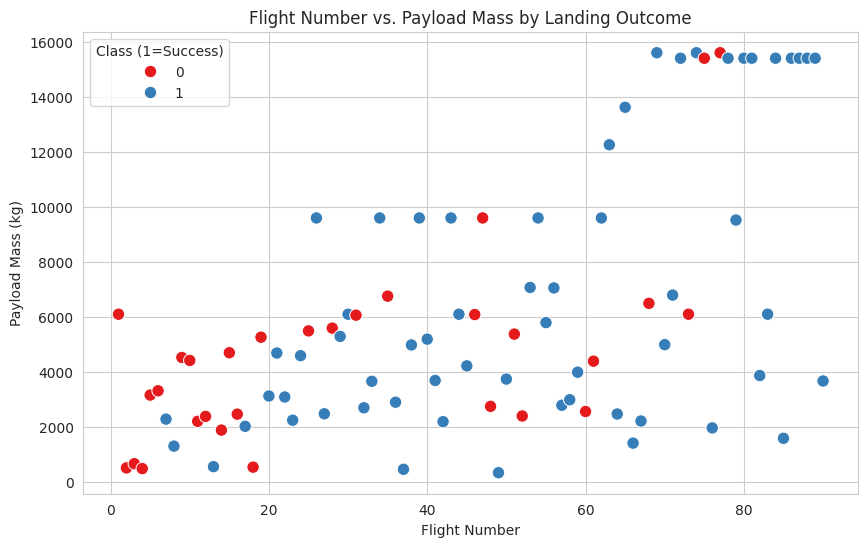

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='PayloadMass', hue='Class', palette='Set1', s=80)
plt.xlabel('Flight Number')
plt.ylabel('Payload Mass (kg)')
plt.title('Flight Number vs. Payload Mass by Landing Outcome')
plt.legend(title='Class (1=Success)')
plt.show()

## 2. Flight Number vs. Launch Site

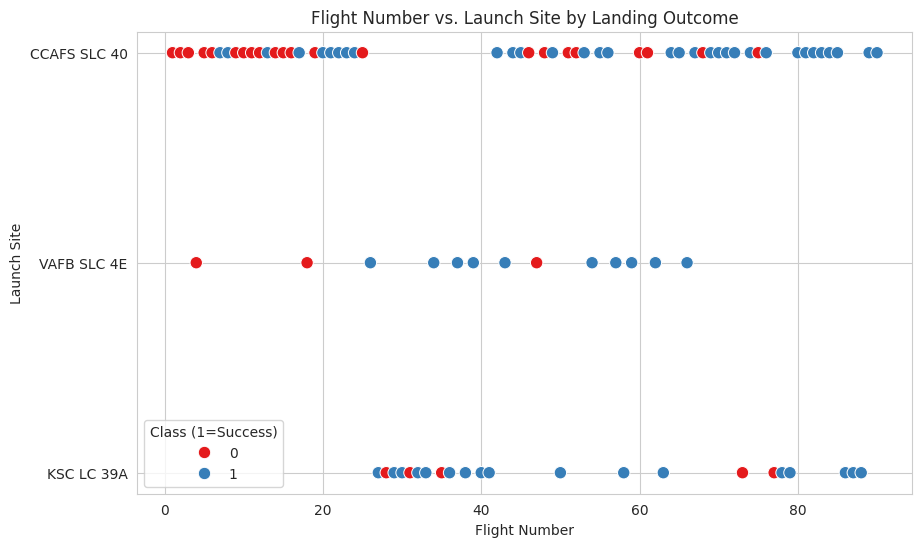

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='LaunchSite', hue='Class', palette='Set1', s=80)
plt.xlabel('Flight Number')
plt.ylabel('Launch Site')
plt.title('Flight Number vs. Launch Site by Landing Outcome')
plt.legend(title='Class (1=Success)')
plt.show()

## 3. Payload Mass vs. Launch Site

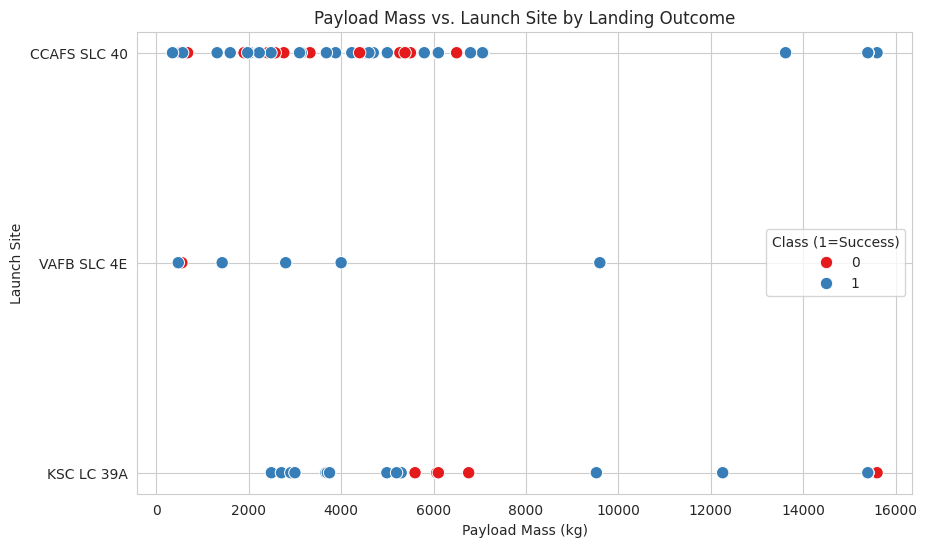

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PayloadMass', y='LaunchSite', hue='Class', palette='Set1', s=80)
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Launch Site')
plt.title('Payload Mass vs. Launch Site by Landing Outcome')
plt.legend(title='Class (1=Success)')
plt.show()

## 4. Success rate by orbit type (bar chart)

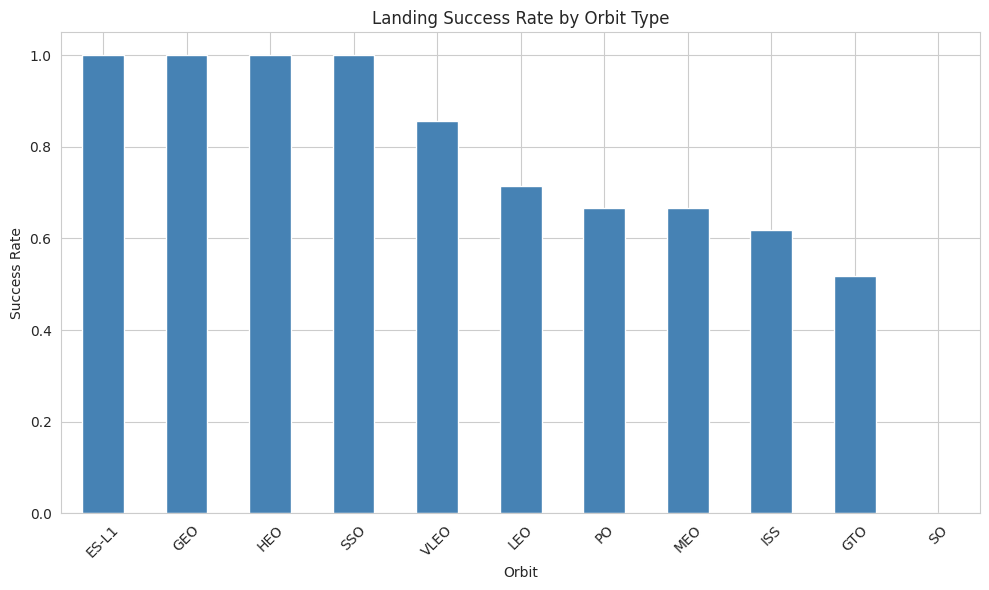

In [33]:
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
orbit_success.plot(kind='bar', color='steelblue')
plt.xlabel('Orbit')
plt.ylabel('Success Rate')
plt.title('Landing Success Rate by Orbit Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Flight Number vs. Orbit

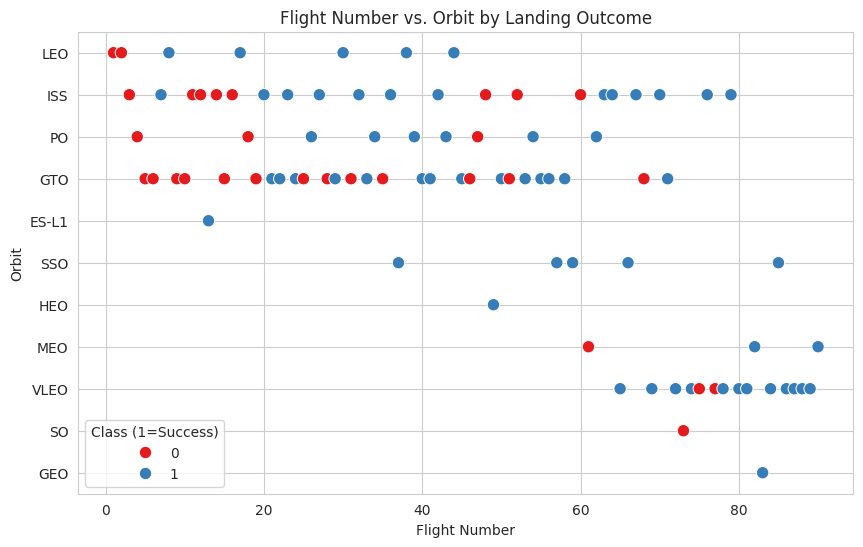

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='Orbit', hue='Class', palette='Set1', s=80)
plt.xlabel('Flight Number')
plt.ylabel('Orbit')
plt.title('Flight Number vs. Orbit by Landing Outcome')
plt.legend(title='Class (1=Success)')
plt.show()

## 6. Payload Mass vs. Orbit

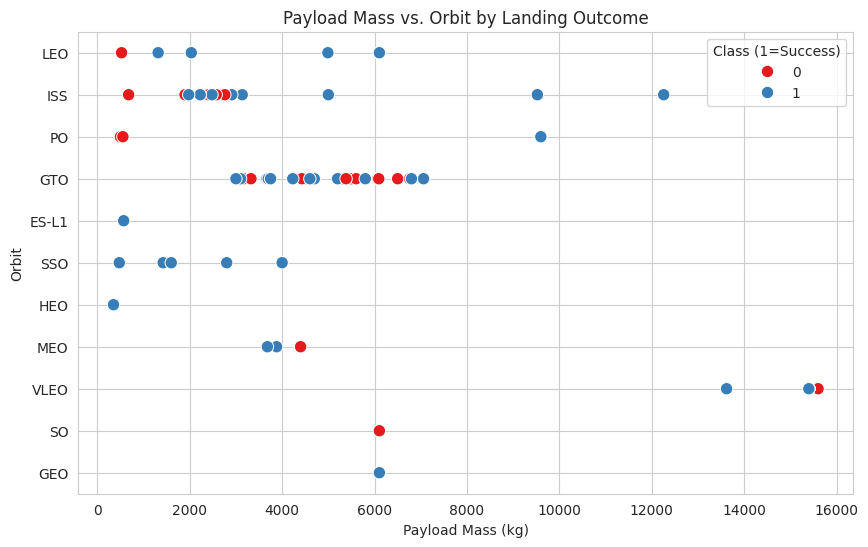

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PayloadMass', y='Orbit', hue='Class', palette='Set1', s=80)
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Orbit')
plt.title('Payload Mass vs. Orbit by Landing Outcome')
plt.legend(title='Class (1=Success)')
plt.show()

## 7. Yearly launch success trend
This is the key "yearly trends" chart required by the grading rubric.

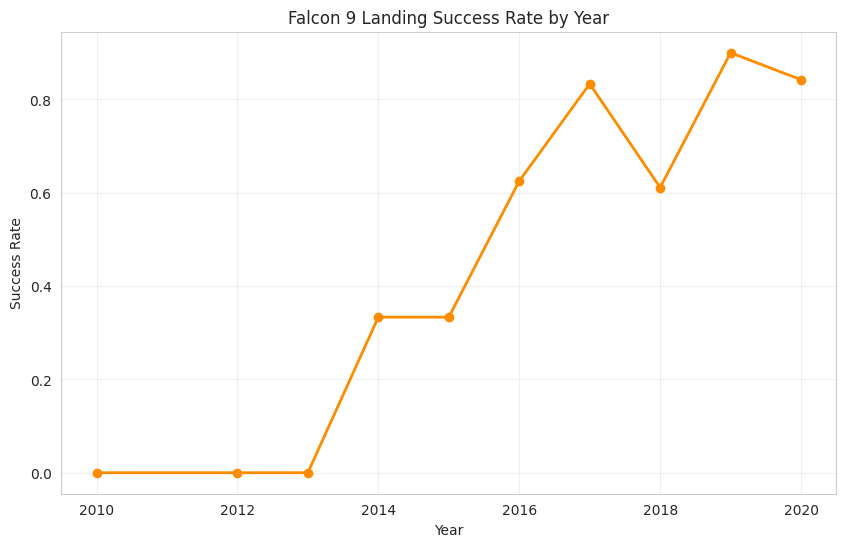

In [36]:
df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly_success = df.groupby('Year')['Class'].mean()

plt.figure(figsize=(10, 6))
plt.plot(yearly_success.index, yearly_success.values, marker='o', linewidth=2, color='darkorange')
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.title('Falcon 9 Landing Success Rate by Year')
plt.grid(True, alpha=0.3)
plt.show()

## 8. Feature engineering: one-hot encode categorical columns
This produces the numeric feature matrix used later for machine learning (Lab 8).

In [37]:
features_to_encode = ['Orbit', 'LaunchSite', 'LandingPad', 'Serial']
features_one_hot = pd.get_dummies(df[['FlightNumber', 'PayloadMass', 'Flights', 'GridFins',
                                        'Reused', 'Legs', 'Block', 'ReusedCount'] + features_to_encode],
                                   columns=features_to_encode)
features_one_hot = features_one_hot.astype('float64')
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)
print('Saved dataset_part_3.csv with', features_one_hot.shape[0], 'rows and', features_one_hot.shape[1], 'columns')

Saved dataset_part_3.csv with 90 rows and 80 columns


---
# LAB 5: EDA with SQL

In [39]:
import pandas as pd
import sqlite3
import os

## 0. Load the dataset and create the SQL table

In [40]:
if os.path.exists('dataset_part_2.csv'):
    df = pd.read_csv('dataset_part_2.csv')
else:
    print('dataset_part_2.csv not found locally, loading from IBM dataset repository...')
    fallback_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv'
    df = pd.read_csv(fallback_url)

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

conn = sqlite3.connect(':memory:')
df.to_sql('SPACEXTABLE', conn, index=False, if_exists='replace')

print('Table loaded with', df.shape[0], 'rows')
pd.read_sql("SELECT * FROM SPACEXTABLE LIMIT 5", conn)

Table loaded with 90 rows


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class,Year,Month
0,1,2010-06-04 00:00:00,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,0,0,0,None,1.0,0,B0003,-80.577366,28.561857,0,2010,June
1,2,2012-05-22 00:00:00,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,0,0,0,None,1.0,0,B0005,-80.577366,28.561857,0,2012,May
2,3,2013-03-01 00:00:00,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,0,0,0,None,1.0,0,B0007,-80.577366,28.561857,0,2013,March
3,4,2013-09-29 00:00:00,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,0,0,0,None,1.0,0,B1003,-120.610829,34.632093,0,2013,September
4,5,2013-12-03 00:00:00,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,0,0,0,None,1.0,0,B1004,-80.577366,28.561857,0,2013,December


## 1. Distinct launch sites used in the missions

In [41]:
pd.read_sql("SELECT DISTINCT LaunchSite FROM SPACEXTABLE", conn)

,LaunchSite
0,CCAFS SLC 40
1,VAFB SLC 4E
2,KSC LC 39A


## 2. Total and average payload mass by launch site

In [42]:
pd.read_sql("""
SELECT LaunchSite,
       COUNT(*) AS TotalLaunches,
       ROUND(SUM(PayloadMass), 1) AS TotalPayloadMass,
       ROUND(AVG(PayloadMass), 1) AS AvgPayloadMass
FROM SPACEXTABLE
GROUP BY LaunchSite
ORDER BY TotalLaunches DESC
""", conn)

,LaunchSite,TotalLaunches,TotalPayloadMass,AvgPayloadMass
0,CCAFS SLC 40,55,305151.4,5548.2
1,KSC LC 39A,22,167341.9,7606.5
2,VAFB SLC 4E,13,76953.0,5919.5


## 3. Overall and per-site landing success rate

In [43]:
print("Overall success rate:")
display(pd.read_sql("SELECT ROUND(AVG(Class) * 100, 1) AS SuccessRatePct FROM SPACEXTABLE", conn))

print("Success rate by launch site:")
display(pd.read_sql("""
SELECT LaunchSite,
       COUNT(*) AS TotalLaunches,
       SUM(Class) AS SuccessfulLandings,
       ROUND(AVG(Class) * 100, 1) AS SuccessRatePct
FROM SPACEXTABLE
GROUP BY LaunchSite
ORDER BY SuccessRatePct DESC
""", conn))

Overall success rate:


,SuccessRatePct
0,66.7


Success rate by launch site:


,LaunchSite,TotalLaunches,SuccessfulLandings,SuccessRatePct
0,KSC LC 39A,22,17,77.3
1,VAFB SLC 4E,13,10,76.9
2,CCAFS SLC 40,55,33,60.0


## 4. Ranking landing outcome types by frequency

In [44]:
pd.read_sql("""
SELECT Outcome, COUNT(*) AS Frequency
FROM SPACEXTABLE
GROUP BY Outcome
ORDER BY Frequency DESC
""", conn)

,Outcome,Frequency
0,True ASDS,41
1,None None,19
2,True RTLS,14
3,False ASDS,6
4,True Ocean,5
5,None ASDS,2
6,False Ocean,2
7,False RTLS,1


## 5. Booster with the maximum payload mass carried

In [45]:
pd.read_sql("""
SELECT BoosterVersion, Serial, PayloadMass, LaunchSite, Date
FROM SPACEXTABLE
WHERE PayloadMass = (SELECT MAX(PayloadMass) FROM SPACEXTABLE)
""", conn)

,BoosterVersion,Serial,PayloadMass,LaunchSite,Date
0,Falcon 9,B1048,15600.0,CCAFS SLC 40,2019-11-11 00:00:00
1,Falcon 9,B1051,15600.0,CCAFS SLC 40,2020-01-29 00:00:00
2,Falcon 9,B1048,15600.0,KSC LC 39A,2020-03-18 00:00:00


## 6. Date of the first successful landing

In [46]:
pd.read_sql("""
SELECT MIN(Date) AS FirstSuccessfulLanding
FROM SPACEXTABLE
WHERE Class = 1
""", conn)

,FirstSuccessfulLanding
0,2014-04-18 00:00:00


## 7. Success rate trend by year (time analysis)

In [47]:
pd.read_sql("""
SELECT Year,
       COUNT(*) AS TotalLaunches,
       SUM(Class) AS SuccessfulLandings,
       ROUND(AVG(Class) * 100, 1) AS SuccessRatePct
FROM SPACEXTABLE
GROUP BY Year
ORDER BY Year
""", conn)

,Year,TotalLaunches,SuccessfulLandings,SuccessRatePct
0,2010,1,0,0.0
1,2012,1,0,0.0
2,2013,3,0,0.0
3,2014,6,2,33.3
4,2015,6,2,33.3
5,2016,8,5,62.5
6,2017,18,15,83.3
7,2018,18,11,61.1
8,2019,10,9,90.0
9,2020,19,16,84.2


## 8. Boosters that failed to land in months with a specific pattern (example: 2015 failures by month)

In [48]:
pd.read_sql("""
SELECT Month, Date, BoosterVersion, LaunchSite, Outcome
FROM SPACEXTABLE
WHERE Year = 2015 AND Class = 0
""", conn)

,Month,Date,BoosterVersion,LaunchSite,Outcome
0,January,2015-01-10 00:00:00,Falcon 9,CCAFS SLC 40,False ASDS
1,April,2015-04-14 00:00:00,Falcon 9,CCAFS SLC 40,False ASDS
2,April,2015-04-27 00:00:00,Falcon 9,CCAFS SLC 40,None None
3,June,2015-06-28 00:00:00,Falcon 9,CCAFS SLC 40,None ASDS


## 9. Payload mass ranking within a specific date range

In [49]:
pd.read_sql("""
SELECT Outcome, COUNT(*) AS Frequency
FROM SPACEXTABLE
WHERE Date BETWEEN '2010-06-04' AND '2017-03-20'
GROUP BY Outcome
ORDER BY Frequency DESC
""", conn)

,Outcome,Frequency
0,None None,9
1,True ASDS,5
2,False ASDS,4
3,True RTLS,3
4,True Ocean,3
5,None ASDS,2
6,False Ocean,2


---
# LAB 6: Interactive Visual Analytics - Folium Map

In [50]:
!pip install folium -q

In [51]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster, MousePosition
from folium.features import DivIcon
from math import sin, cos, sqrt, atan2, radians
import os

## 0. Load the dataset

In [52]:
if os.path.exists('dataset_part_2.csv'):
    df = pd.read_csv('dataset_part_2.csv')
else:
    print('dataset_part_2.csv not found locally, loading from IBM dataset repository...')
    fallback_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv'
    df = pd.read_csv(fallback_url)

launch_sites_df = df.groupby('LaunchSite', as_index=False).first()[['LaunchSite', 'Latitude', 'Longitude']]
launch_sites_df

,LaunchSite,Latitude,Longitude
0,CCAFS SLC 40,28.561857,-80.577366
1,KSC LC 39A,28.608058,-80.603956
2,VAFB SLC 4E,34.632093,-120.610829


## 1. Base map with a marker for every launch site

In [53]:
site_map = folium.Map(location=[28.5, -80.5], zoom_start=4.5)

for _, row in launch_sites_df.iterrows():
    coordinate = [row['Latitude'], row['Longitude']]
    circle = folium.Circle(coordinate, radius=1000, color='#d35400', fill=True).add_child(
        folium.Popup(row['LaunchSite'])
    )
    marker = folium.map.Marker(
        coordinate,
        icon=DivIcon(
            icon_size=(20, 20),
            icon_anchor=(0, 0),
            html=f'<div style="font-size: 12px; color:#d35400;"><b>{row["LaunchSite"]}</b></div>'
        )
    )
    site_map.add_child(circle)
    site_map.add_child(marker)

site_map

## 2. Mark every individual launch, colored green (success) / red (failure)

In [54]:
marker_cluster = MarkerCluster()
df['marker_color'] = df['Class'].apply(lambda x: 'green' if x == 1 else 'red')

site_map2 = folium.Map(location=[28.5, -80.5], zoom_start=4.5)
site_map2.add_child(marker_cluster)

for _, record in df.iterrows():
    marker = folium.Marker(
        [record['Latitude'], record['Longitude']],
        icon=folium.Icon(color='white', icon_color=record['marker_color']),
        popup=f"{record['LaunchSite']} — {'Success' if record['Class']==1 else 'Failure'}"
    )
    marker_cluster.add_child(marker)

site_map2

## 3. Proximity analysis: distance from a launch site to the coastline
We use the Haversine formula. Coordinates below are for the coastline point nearest **KSC LC-39A** — if your report focuses on a different site, replace `coastline_lat/lon` with the nearest coastline point you find on the map for that site (right-click on the map in Colab, use MousePosition to read coordinates).

In [55]:
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6373.0  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

# See the exact site names available in your data:
print(launch_sites_df['LaunchSite'].tolist())

# Pick a site by partial match instead of an exact hardcoded string, so this
# works regardless of exact spacing/formatting in your dataset (e.g. 'KSC LC-39A',
# 'KSC LC 39A', 'CCAFS LC-40', etc). Change the search text below if needed.
site_search = 'KSC'
matches = launch_sites_df[launch_sites_df['LaunchSite'].str.contains(site_search, case=False)]

if matches.empty:
    # fall back to the first available site if the search text doesn't match anything
    chosen_site = launch_sites_df.iloc[0]
else:
    chosen_site = matches.iloc[0]

site_name = chosen_site['LaunchSite']
launch_site_lat = chosen_site['Latitude']
launch_site_lon = chosen_site['Longitude']
print(f"Using site: {site_name} ({launch_site_lat}, {launch_site_lon})")

# Nearest coastline point (approximate, read from map -- adjust if you picked a different site)
coastline_lat = 28.56367
coastline_lon = -80.57163

distance_coastline = calculate_distance(launch_site_lat, launch_site_lon, coastline_lat, coastline_lon)
print(f"Distance from {site_name} to nearest coastline: {distance_coastline:.2f} km")

['CCAFS SLC 40', 'KSC LC 39A', 'VAFB SLC 4E']
Using site: KSC LC 39A (28.6080585, -80.6039558)
Distance from KSC LC 39A to nearest coastline: 5.86 km


In [56]:
proximity_map = folium.Map(location=[launch_site_lat, launch_site_lon], zoom_start=12)

folium.Marker([launch_site_lat, launch_site_lon], popup=site_name,
              icon=folium.Icon(color='orange')).add_to(proximity_map)
folium.Marker([coastline_lat, coastline_lon], popup='Nearest coastline point',
              icon=folium.Icon(color='blue')).add_to(proximity_map)

folium.PolyLine(locations=[[launch_site_lat, launch_site_lon], [coastline_lat, coastline_lon]],
                 weight=2, color='blue').add_to(proximity_map)
folium.map.Marker(
    [(launch_site_lat + coastline_lat) / 2, (launch_site_lon + coastline_lon) / 2],
    icon=DivIcon(icon_size=(20, 20), icon_anchor=(0, 0),
                 html=f'<div style="font-size:12px;color:#252850;"><b>{distance_coastline:.2f} KM</b></div>')
).add_to(proximity_map)

proximity_map

## 4. Save maps as standalone HTML (for your GitHub repo / slides)

In [57]:
site_map.save('launch_sites_map.html')
site_map2.save('launch_outcomes_map.html')
proximity_map.save('proximity_analysis_map.html')
print('Saved 3 HTML maps')

Saved 3 HTML maps


---
# LAB 8: Predictive Analysis (Machine Learning)

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, jaccard_score, f1_score, classification_report

sns.set_style('whitegrid')
%matplotlib inline

## 0. Load the target (`Class`) and the one-hot encoded feature matrix
`dataset_part_2.csv` (Lab 3) has the target `Class`. `dataset_part_3.csv` (Lab 4) has the one-hot encoded numeric features.

In [59]:
def load_or_fallback(local_name, fallback_url):
    if os.path.exists(local_name):
        return pd.read_csv(local_name)
    print(f'{local_name} not found locally, loading from IBM dataset repository...')
    return pd.read_csv(fallback_url)

data = load_or_fallback(
    'dataset_part_2.csv',
    'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv'
)
X = load_or_fallback(
    'dataset_part_3.csv',
    'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
)

Y = data['Class'].to_numpy()
print('Features shape:', X.shape, '| Target shape:', Y.shape)
X.head()

Features shape: (90, 80) | Target shape: (90,)


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Standardize features and split into train/test sets

In [60]:
X = X.astype(float)
transform = preprocessing.StandardScaler()
X_scaled = transform.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=2)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])

Train size: 72 | Test size: 18


## 2. Helper to plot a confusion matrix

In [61]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Failure', 'Success'], yticklabels=['Failure', 'Success'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

## 3. Logistic Regression (with GridSearchCV)

Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.8214285714285714
Test accuracy: 0.8333333333333334


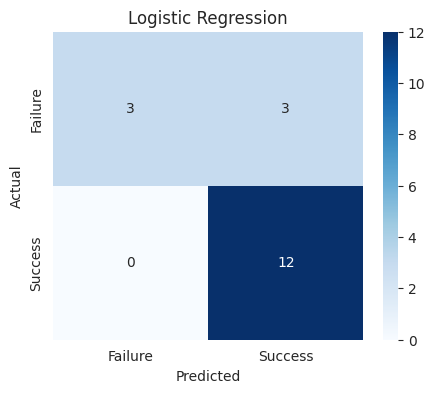

In [62]:
parameters_lr = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr = LogisticRegression(max_iter=1000)
logreg_cv = GridSearchCV(lr, parameters_lr, cv=10)
logreg_cv.fit(X_train, Y_train)

print('Best params:', logreg_cv.best_params_)
print('Best CV accuracy:', logreg_cv.best_score_)

lr_test_acc = logreg_cv.score(X_test, Y_test)
print('Test accuracy:', lr_test_acc)

yhat_lr = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_lr, 'Logistic Regression')

## 4. Support Vector Machine (with GridSearchCV)

Best params: {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Best CV accuracy: 0.8482142857142858
Test accuracy: 0.8333333333333334


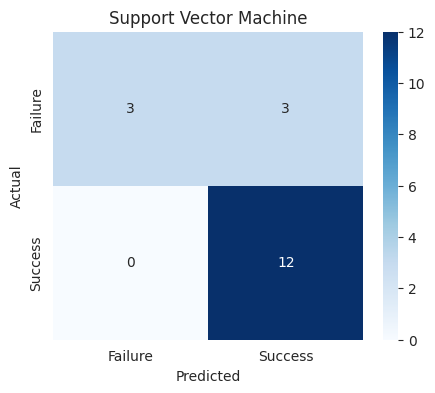

In [63]:
parameters_svm = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
                   'C': np.logspace(-3, 3, 5),
                   'gamma': np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters_svm, cv=10)
svm_cv.fit(X_train, Y_train)

print('Best params:', svm_cv.best_params_)
print('Best CV accuracy:', svm_cv.best_score_)

svm_test_acc = svm_cv.score(X_test, Y_test)
print('Test accuracy:', svm_test_acc)

yhat_svm = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_svm, 'Support Vector Machine')

## 5. Decision Tree (with GridSearchCV)

Best params: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
Best CV accuracy: 0.8339285714285714
Test accuracy: 0.7222222222222222


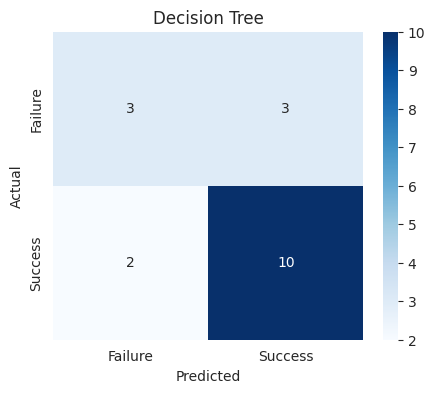

In [64]:
parameters_tree = {'criterion': ['gini', 'entropy'],
                    'splitter': ['best', 'random'],
                    'max_depth': [2*n for n in range(1, 10)],
                    'max_features': ['sqrt'],
                    'min_samples_leaf': [1, 2, 4],
                    'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier(random_state=2)
tree_cv = GridSearchCV(tree, parameters_tree, cv=10)
tree_cv.fit(X_train, Y_train)

print('Best params:', tree_cv.best_params_)
print('Best CV accuracy:', tree_cv.best_score_)

tree_test_acc = tree_cv.score(X_test, Y_test)
print('Test accuracy:', tree_test_acc)

yhat_tree = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_tree, 'Decision Tree')

## 6. K-Nearest Neighbors (with GridSearchCV)

Best params: {'algorithm': 'auto', 'n_neighbors': 6, 'p': 1}
Best CV accuracy: 0.8339285714285714
Test accuracy: 0.8333333333333334


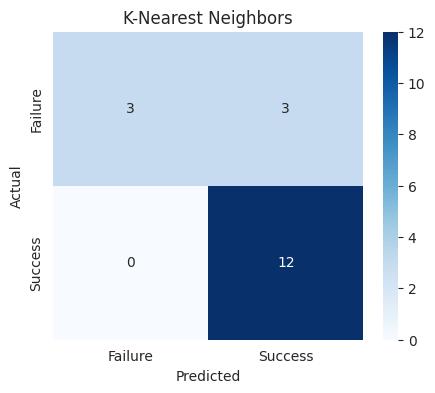

In [65]:
parameters_knn = {'n_neighbors': list(range(1, 11)),
                   'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                   'p': [1, 2]}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters_knn, cv=10)
knn_cv.fit(X_train, Y_train)

print('Best params:', knn_cv.best_params_)
print('Best CV accuracy:', knn_cv.best_score_)

knn_test_acc = knn_cv.score(X_test, Y_test)
print('Test accuracy:', knn_test_acc)

yhat_knn = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_knn, 'K-Nearest Neighbors')

## 7. Compare all models and pick the best one

In [66]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN'],
    'Best CV Accuracy': [logreg_cv.best_score_, svm_cv.best_score_, tree_cv.best_score_, knn_cv.best_score_],
    'Test Accuracy': [lr_test_acc, svm_test_acc, tree_test_acc, knn_test_acc]
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

results

,Model,Best CV Accuracy,Test Accuracy
0,Logistic Regression,0.821429,0.833333
1,SVM,0.848214,0.833333
2,KNN,0.833929,0.833333
3,Decision Tree,0.833929,0.722222


/tmp/ipykernel_2178/4057490833.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='Test Accuracy', palette='viridis')


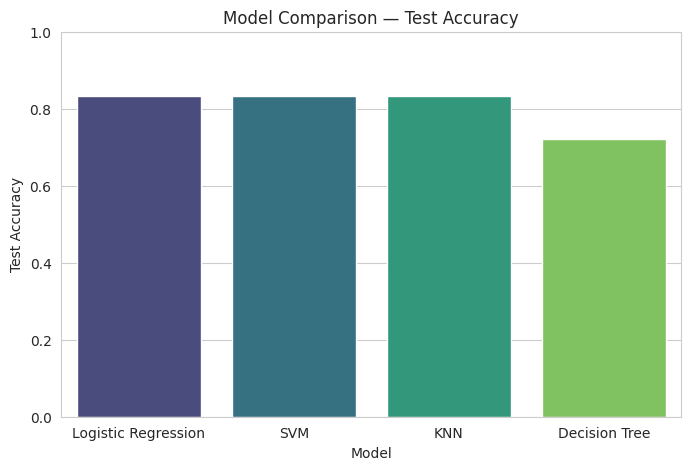

Best performing model: Logistic Regression
              Model  Best CV Accuracy  Test Accuracy
Logistic Regression          0.821429       0.833333
                SVM          0.848214       0.833333
                KNN          0.833929       0.833333
      Decision Tree          0.833929       0.722222


In [67]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x='Model', y='Test Accuracy', palette='viridis')
plt.ylim(0, 1)
plt.title('Model Comparison — Test Accuracy')
plt.ylabel('Test Accuracy')
plt.show()

best_model_name = results.iloc[0]['Model']
print(f"Best performing model: {best_model_name}")
print(results.to_string(index=False))

## 8. Write-up for your slide (1.15)
Fill this in with your actual printed numbers once you've run the notebook:

- **Best model:** *(fill in from the table above)*
- **Why it won:** compare test accuracy and how well it balances false positives (predicting success when it failed) vs. false negatives (predicting failure when it succeeded) using the confusion matrix.
- **Conclusion:** summarize what features seemed to drive success (recall your EDA — flight number, orbit type, payload mass) and what this means for predicting future launch outcomes.

---
# Final Step: Package Everything for Download

In [68]:
import shutil
import glob

output_files = (
    glob.glob('*.csv') +
    glob.glob('*.html')
)
print('Files found to package:')
for f in output_files:
    print(' -', f)

import os
os.makedirs('spacex_capstone_outputs', exist_ok=True)
for f in output_files:
    shutil.copy(f, 'spacex_capstone_outputs/')

shutil.make_archive('spacex_capstone_outputs', 'zip', 'spacex_capstone_outputs')
print('\nCreated spacex_capstone_outputs.zip')

try:
    from google.colab import files
    files.download('spacex_capstone_outputs.zip')
except ImportError:
    print('Not running in Colab -- find spacex_capstone_outputs.zip in the file panel and download manually.')

Files found to package:
 - dataset_part_2.csv
 - spacex_web_scraped.csv
 - dataset_part_3.csv
 - dataset_part_1.csv
 - proximity_analysis_map.html
 - launch_sites_map.html
 - launch_outcomes_map.html

Created spacex_capstone_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>